## Figure 1 of manuscript showing shapshot of SIC, SSS, and SST for ice bridge

In [1]:
## import required packages
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from pyproj import Proj, Transformer
import glob
import os
import string
from datetime import datetime

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:37841")
client

<Client: 'tcp://127.0.0.1:37841' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# Set data directory and load all matching NetCDF files
data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr"
sic_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sss_rss_smap"
sss_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

data_dir = "/home/jpluser/efs-mount-point/mzahn/satellite_data/sst_noaa_oisst"
sst_file_paths_2022 = sorted(glob.glob(os.path.join(data_dir, "*2022*.nc")))

Plot 2x4 plot

In [9]:
# select specific dates for fig 1
sic_file_paths = [[item for item in sic_file_paths_2022 if '20220928' in item][0]]

In [10]:
# sss is reported in DOY not mon/day
dates = ['20220928']
for date_str in dates:
    dt = datetime.strptime(date_str, '%Y%m%d')
    doy = dt.timetuple().tm_yday
    print(f"{date_str} -> DOY {doy}")

20220928 -> DOY 271


In [11]:
# The SMAP radiometer was put in safehold mode during Julian days 218 – 265 (06 AUG – 21
# SEP) in 2022. No L2C and 8-day L3 files are available during this time period. No monthly L3
# files are produced for AUG – SEP 2022
len(sss_file_paths_2022)

317

In [12]:
# select specific dates for fig 1
sss_file_paths = [[item for item in sss_file_paths_2022 if '2022_271' in item][0]]

In [14]:
# select specific dates for fig 1
sst_file_paths = [[item for item in sst_file_paths_2022 if '20220928' in item][0]]

In [15]:
def remap_colormap(cmap, nonlin_scale=np.sqrt, n=256):
    """
    Remap a colormap so that lower values are compressed (darker colors take up less space),
    and higher values (lighter colors) are stretched out.
    
    Parameters:
    - cmap: The original colormap (e.g., cmocean.cm.ice)
    - nonlin_scale: A function that maps [0,1] -> [0,1] nonlinearly (default: np.sqrt)
    - n: Number of color levels
    
    Returns:
    - A new colormap with redistributed colors.
    """
    # Generate linearly spaced values, then apply non-linear scaling
    orig_vals = np.linspace(0, 1, n)
    remapped_vals = nonlin_scale(orig_vals)

    # Normalize remapped values to stay in [0,1]
    remapped_vals = (remapped_vals - remapped_vals.min()) / (remapped_vals.max() - remapped_vals.min())

    # Map those values through the original colormap
    new_colors = cmap(remapped_vals)
    
    return LinearSegmentedColormap.from_list(f'remapped_{cmap.name}', new_colors, N=n)

In [16]:
from matplotlib.colors import LinearSegmentedColormap

# create a nonlinearly adjusted colormap from the cmocean ice colormap
custom_ice_cmap = remap_colormap(cmocean.cm.ice, nonlin_scale=np.sqrt)  # sqrt compresses low end

In [17]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

# get lat/lon coordinates of model box
grid_beaufort = HH_grid.isel(i=slice(510,750),j=slice(110,390))

In [18]:
print(grid_beaufort.Z.values[0:17])
print(grid_beaufort.drF.values[0:17])

[ -0.5    -1.57   -2.79   -4.185  -5.78   -7.595  -9.66  -12.01  -14.68
 -17.705 -21.125 -24.99  -29.345 -34.24  -39.725 -45.855 -52.69 ]
[1.   1.14 1.3  1.49 1.7  1.93 2.2  2.5  2.84 3.21 3.63 4.1  4.61 5.18
 5.79 6.47 7.2 ]


Map of area

In [21]:
bathy_ds = xr.open_dataset('/home/jpluser/efs-mount-point/mzahn/bathy/gebco_2024_n90.0_s50.0_w-180.0_e180.0.nc')

In [22]:
bathy = bathy_ds.elevation*-1 # make increasing positive with depth

In [25]:
sic_file_paths

['/home/jpluser/efs-mount-point/mzahn/satellite_data/sic_nsidc_cdr/sic_psn25_20220928_F17_v05r00.nc']

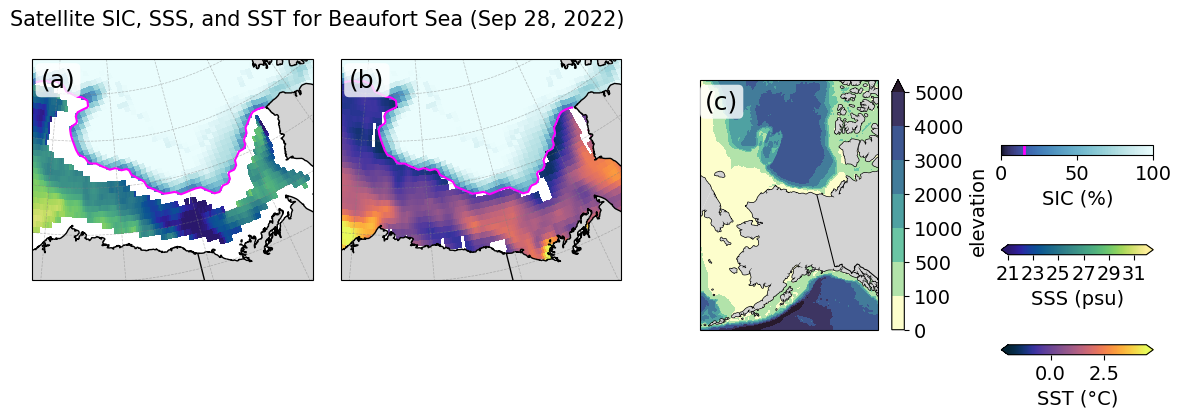

In [32]:
plt.rcParams['font.size'] = 14

# Define NSIDC stereographic projection
nsidc_proj = Proj(proj='stere', lat_0=90, lon_0=-45, lat_ts=70,
                  a=6378273, b=6356889.449, units='m')
transformer = Transformer.from_proj(nsidc_proj, "epsg:4326", always_xy=True)

# Create 4x2 plot
fig, axes = plt.subplots(1, 2, figsize=(7.6, 5),
                         subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-155)})
plt.subplots_adjust(wspace=0.1, hspace=0.15, right=0.9, top=0.93)
axes = axes.reshape(1, 2)

labels = list(string.ascii_lowercase)  # ['a', 'b', 'c' etc]
pcolormesh_handle = None  # for SIC colorbar

# To hold handles for SSS/SST colorbars
sss_im_list = []
sst_im_list = []

for i in range(len(sic_file_paths)):
    # Load SIC and convert
    sic_ds = xr.open_dataset(sic_file_paths[i])
    sic = sic_ds['cdr_seaice_conc'].squeeze()
    if sic.max() > 1.5:
        sic = sic / 100.0
    sic_masked = np.where(sic > 0.15, sic, np.nan)

    # Load SSS and SST
    sss = xr.open_dataset(sss_file_paths[i])['sss_smap'].squeeze()
    sst = xr.open_dataset(sst_file_paths[i])['sst'].squeeze()
    sst_ice = xr.open_dataset(sst_file_paths[i])['ice'].squeeze()

    # Get grid and lat/lon
    x = sic_ds['x'].values
    y = sic_ds['y'].values
    X, Y = np.meshgrid(x, y)
    lon, lat = transformer.transform(X, Y)

    # Define custom row labels
    row_titles = ["Satellite SIC, SSS, and SST for Beaufort Sea"]
    
    # Define title with date
    dt = pd.to_datetime(sic_ds['time'].values)
    date_str = dt.strftime('%b %d, %Y')
    row_title = f"{row_titles[i]} ({date_str[0]})"

    # Determine top y-position of the row using both subplots in the row
    row_top_y = max(axes[i, 0].get_position().y1, axes[i, 1].get_position().y1)

    # Place title a bit above the top of the row
    fig.text(0.5, row_top_y + 0.008, row_title, ha='center', fontsize=15)

    for j in range(2):  # j=0 (SSS), j=1 (SST)
        ax = axes[i, j]
        ax.set_extent([-161, -127, 69, 77], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', facecolor='lightgray'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'))
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        gl = ax.gridlines(draw_labels=False, linewidth=0.5, color='gray',
                          alpha=0.5, linestyle='--', ylocs=[67, 69, 71, 73, 75, 77, 79])

        # Plot SSS and SST
        if j == 0:
            sss_cb = sss.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.haline,
                          vmin=21, vmax=32, add_colorbar=False, extend='both')
        else:
            sst_cb = sst.where(sst_ice.isnull()).plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal,
                          vmin=-2, vmax=4.5, add_colorbar=False, extend='both')

        # Overlay SIC on top
        sic_cb = ax.pcolormesh(lon, lat, sic_masked * 100, transform=ccrs.PlateCarree(),
                               cmap=custom_ice_cmap, shading='auto', vmin=0, vmax=100)

        ax.set_title("")
        
        # Add 15% contour
        regional_mask = ((lon >= -165) & (lon <= -120) & (lat >= 66) & (lat <= 80))
        sic_region = np.where(regional_mask, sic, np.nan)
        ax.contour(lon, lat, sic_region * 100, levels=[15], colors='magenta',
                   linewidths=1.5, transform=ccrs.PlateCarree())

        # Subplot label
        ax.text(0.03, 0.96, f'({labels[i * 2 + j]})', transform=ax.transAxes,
                fontsize=18, va='top', ha='left',
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.8))

# Shared SSS colorbar under left column
cbar_ax_sss = fig.add_axes([1.4, 0.35, 0.2, 0.02])  # [left, bottom, width, height]
cb_sss = fig.colorbar(sss_cb, cax=cbar_ax_sss, orientation='horizontal', extend='both')
cb_sss.set_label('SSS (psu)')
cb_sss.set_ticks([21,23,25,27,29,31])

cbar_ax_sic = fig.add_axes([1.4, 0.55, 0.2, 0.02])  # [left, bottom, width, height]
cb_sic = fig.colorbar(sic_cb, cax=cbar_ax_sic, orientation='horizontal')
cb_sic.set_label('SIC (%)')
cb_sic.ax.vlines(15, *cb_sic.ax.get_xlim(), colors='magenta', linewidth=2)

# Shared SST colorbar under right column
cbar_ax_sst = fig.add_axes([1.4, 0.15, 0.2, 0.02])
cb_sst = fig.colorbar(sst_cb, cax=cbar_ax_sst, orientation='horizontal', extend='both')
cb_sst.set_label('SST (°C)')

# Create inset axes in the upper-right corner of the figure -------------------
inset_ax = fig.add_axes([0.95, 0.2, 0.36, 0.5], projection=ccrs.NorthPolarStereo(central_longitude=-155))

# Plot subsampled bathymetry
bathy_select = bathy.isel(lat=slice(None,None,50), lon=slice(None,None,50))
bathy_levels=[0,100,500,1000,2000,3000,4000,5000]
bathy_cb = bathy_select.where(bathy_select>=0).plot.contourf(
    ax=inset_ax,
    cmap=cmocean.cm.deep,
    vmin=0, vmax=4000,
    levels=bathy_levels,
    add_colorbar=True,
    transform=ccrs.PlateCarree()
)

# Add map features
inset_ax.coastlines(resolution='50m', linewidth=1,zorder=2)
inset_ax.add_feature(cfeature.BORDERS, linewidth=0.75,zorder=3)
inset_ax.add_feature(cfeature.LAND, facecolor='lightgray',zorder=2)

# Set extent for broader Arctic region
inset_ax.set_extent([-171, -135, 53, 85], crs=ccrs.PlateCarree())

# Optional: Title for inset
inset_ax.set_title("", fontsize=15)

# Subplot label
inset_ax.text(0.03, 0.96, '(c)',transform=inset_ax.transAxes,
        fontsize=18, va='top', ha='left',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2', alpha=0.8))

# # add colorbar for bathy
# cbar_ax_bathy = fig.add_axes([0.95, 0.52, 0.2, 0.015])
# cb_bathy = fig.colorbar(bathy_cb, cax=cbar_ax_bathy, boundaries=bathy_levels, ticks=bathy_levels, orientation='horizontal', extend='right')
# cb_bathy.set_label('Depth (m)')
# cb_bathy.ax.tick_params(labelrotation=45)

# Show or save
# fig.savefig('/home/jpluser/git_repos/SASSIE_ECCO_salinity_stratification/figures/fig1.png', dpi=300, bbox_inches='tight')
plt.show()